In [2]:
import pandas as pd

In [3]:
degs_24W_F = pd.read_csv('/Users/derekebowman/Coding Projects/taPVAT_snRNAseq_analysis/code/scVelo_and_CellOracle/CellOracle/DEG_Data/taPVAT_Adipocytes_Brown_HF_24W_F_vs_Control_24W_F_diet_comparison_deseq_all_genes.txt', sep='\t')

In [4]:
predictions_24W_F = pd.read_csv('/Users/derekebowman/Coding Projects/taPVAT_snRNAseq_analysis/code/scVelo_and_CellOracle/CellOracle/scVIDR_Gene_Score_Predictions/August18_10_21_gene_scores_Adipocytes_Brown_24W_F.csv')

In [5]:
predictions_24W_F = predictions_24W_F[~predictions_24W_F['Gene'].str.startswith('Mt-')] # Removed mitochondrial genes
predictions_24W_F = predictions_24W_F[~predictions_24W_F['Gene'].str.startswith('AABR')]
predictions_24W_F = predictions_24W_F[~predictions_24W_F['Gene'].str.startswith('ENSRN')]

In [7]:
degs_24W_F = degs_24W_F[degs_24W_F['padj'] <= 0.05]
degs_24W_F= degs_24W_F[~degs_24W_F['gene_id'].str.startswith('Mt-')] # Removed mitochondrial genes

degs_24W_F = degs_24W_F[~degs_24W_F['gene_id'].str.startswith('AABR')]
degs_24W_F = degs_24W_F[~degs_24W_F['gene_id'].str.startswith('ENSRN')]

degs_24W_F

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,celltype,group,group1,group2
80,AC096301.1,121.441668,1.364508,0.375124,3.637488,2.753102e-04,1.011376e-02,AC096301.1,Adipocytes_Brown,diet,Control,HF
88,AC125757.1,216.047742,2.368498,0.337322,7.021473,2.195416e-12,6.931580e-10,AC125757.1,Adipocytes_Brown,diet,Control,HF
92,Aacs,195.596860,-1.569601,0.471467,-3.329188,8.709960e-04,2.513996e-02,Aacs,Adipocytes_Brown,diet,Control,HF
106,Abca1,190.574263,-1.809655,0.482881,-3.747620,1.785201e-04,7.117652e-03,Abca1,Adipocytes_Brown,diet,Control,HF
111,Abca8,29.391771,1.619339,0.409973,3.949864,7.819558e-05,3.653923e-03,Abca8,Adipocytes_Brown,diet,Control,HF
...,...,...,...,...,...,...,...,...,...,...,...,...
11502,Zfp639,197.782359,1.837249,0.495048,3.711251,2.062371e-04,8.057731e-03,Zfp639,Adipocytes_Brown,diet,Control,HF
11529,Zfp711,32.876030,4.456664,0.608535,7.323601,2.414041e-13,1.044475e-10,Zfp711,Adipocytes_Brown,diet,Control,HF
11579,Zfp958,742.846407,0.790765,0.202446,3.906054,9.381570e-05,4.215211e-03,Zfp958,Adipocytes_Brown,diet,Control,HF
11593,Zfyve26,130.382983,-0.881289,0.281415,-3.131639,1.738337e-03,4.284231e-02,Zfyve26,Adipocytes_Brown,diet,Control,HF


In [8]:
degs_up_in_HF = degs_24W_F[degs_24W_F['log2FoldChange'] >= 1.0]
degs_down_in_HF = degs_24W_F[degs_24W_F['log2FoldChange'] <= -1.0]

In [9]:
degs_up_in_HF

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene_id,celltype,group,group1,group2
80,AC096301.1,121.441668,1.364508,0.375124,3.637488,2.753102e-04,1.011376e-02,AC096301.1,Adipocytes_Brown,diet,Control,HF
88,AC125757.1,216.047742,2.368498,0.337322,7.021473,2.195416e-12,6.931580e-10,AC125757.1,Adipocytes_Brown,diet,Control,HF
111,Abca8,29.391771,1.619339,0.409973,3.949864,7.819558e-05,3.653923e-03,Abca8,Adipocytes_Brown,diet,Control,HF
112,Abca8a,167.053616,1.384633,0.308379,4.490036,7.121112e-06,5.437179e-04,Abca8a,Adipocytes_Brown,diet,Control,HF
127,Abcd2,445.087634,2.368032,0.363406,6.516215,7.210369e-11,1.792160e-08,Abcd2,Adipocytes_Brown,diet,Control,HF
...,...,...,...,...,...,...,...,...,...,...,...,...
11319,Zdhhc15,15.823153,2.421517,0.640222,3.782311,1.553793e-04,6.413924e-03,Zdhhc15,Adipocytes_Brown,diet,Control,HF
11429,Zfp385b,326.272633,3.365510,0.338084,9.954664,2.406342e-23,7.027721e-20,Zfp385b,Adipocytes_Brown,diet,Control,HF
11430,Zfp385c,140.857683,1.423773,0.330394,4.309321,1.637565e-05,1.086933e-03,Zfp385c,Adipocytes_Brown,diet,Control,HF
11502,Zfp639,197.782359,1.837249,0.495048,3.711251,2.062371e-04,8.057731e-03,Zfp639,Adipocytes_Brown,diet,Control,HF


In [14]:
upregulated_predictions_24W_F = predictions_24W_F[predictions_24W_F['Gene'].isin(list(degs_up_in_HF['gene_id']))]
downregulated_predictions_24W_F = predictions_24W_F[predictions_24W_F['Gene'].isin(list(degs_down_in_HF['gene_id']))]

In [19]:
gene_to_logfc = degs_24W_F.set_index('gene_id')['log2FoldChange']
downregulated_predictions_24W_F['GroundTruthLog2FC'] = downregulated_predictions_24W_F['Gene'].map(gene_to_logfc)
upregulated_predictions_24W_F['GroundTruthLog2FC'] = upregulated_predictions_24W_F['Gene'].map(gene_to_logfc)


/tmp/ipykernel_3717469/3915252449.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downregulated_predictions_24W_F['GroundTruthLog2FC'] = downregulated_predictions_24W_F['Gene'].map(gene_to_logfc)
/tmp/ipykernel_3717469/3915252449.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upregulated_predictions_24W_F['GroundTruthLog2FC'] = upregulated_predictions_24W_F['Gene'].map(gene_to_logfc)


In [31]:
upregulated_predictions_24W_F.sort_values(by='Score', inplace=True, ascending=False)
downregulated_predictions_24W_F.sort_values(by='Score', inplace=True, ascending=True)

/tmp/ipykernel_3717469/3012416961.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  upregulated_predictions_24W_F.sort_values(by='Score', inplace=True, ascending=False)
/tmp/ipykernel_3717469/3012416961.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downregulated_predictions_24W_F.sort_values(by='Score', inplace=True, ascending=True)


In [29]:
downregulated_predictions_24W_F

,Unnamed: 0,Gene,Score,GroundTruthLog2FC
109,109,Acaca,-1.481022,-2.739020
1774,1774,Fasn,-1.349035,-4.474441
119,119,Acly,-1.301337,-2.888960
721,721,Cdk14,-0.896057,-1.815206
124,124,Acsl5,-0.871221,-5.201847
...,...,...,...,...
404,404,Bach2,0.501711,-1.091804
1874,1874,Foxn3,0.521917,-1.142710
177,177,Adgrf5,0.820392,-3.834845
3543,3543,Plcb1,0.868724,-1.590938


In [32]:
upregulated_predictions_24W_F

,Unnamed: 0,Gene,Score,GroundTruthLog2FC
248,248,Ank3,1.088470,1.139893
1108,1108,Dlc1,0.732328,1.163295
842,842,Clic4,0.673420,1.600363
414,414,Bcar3,0.423738,1.068088
308,308,Arhgap26,0.420384,1.006415
...,...,...,...,...
1078,1078,Dennd2a,-0.158021,2.075152
2622,2622,LOC120094123,-0.178884,2.398920
3215,3215,Nos1ap,-0.213372,1.051906
2764,2764,Limch1,-0.442646,2.197035


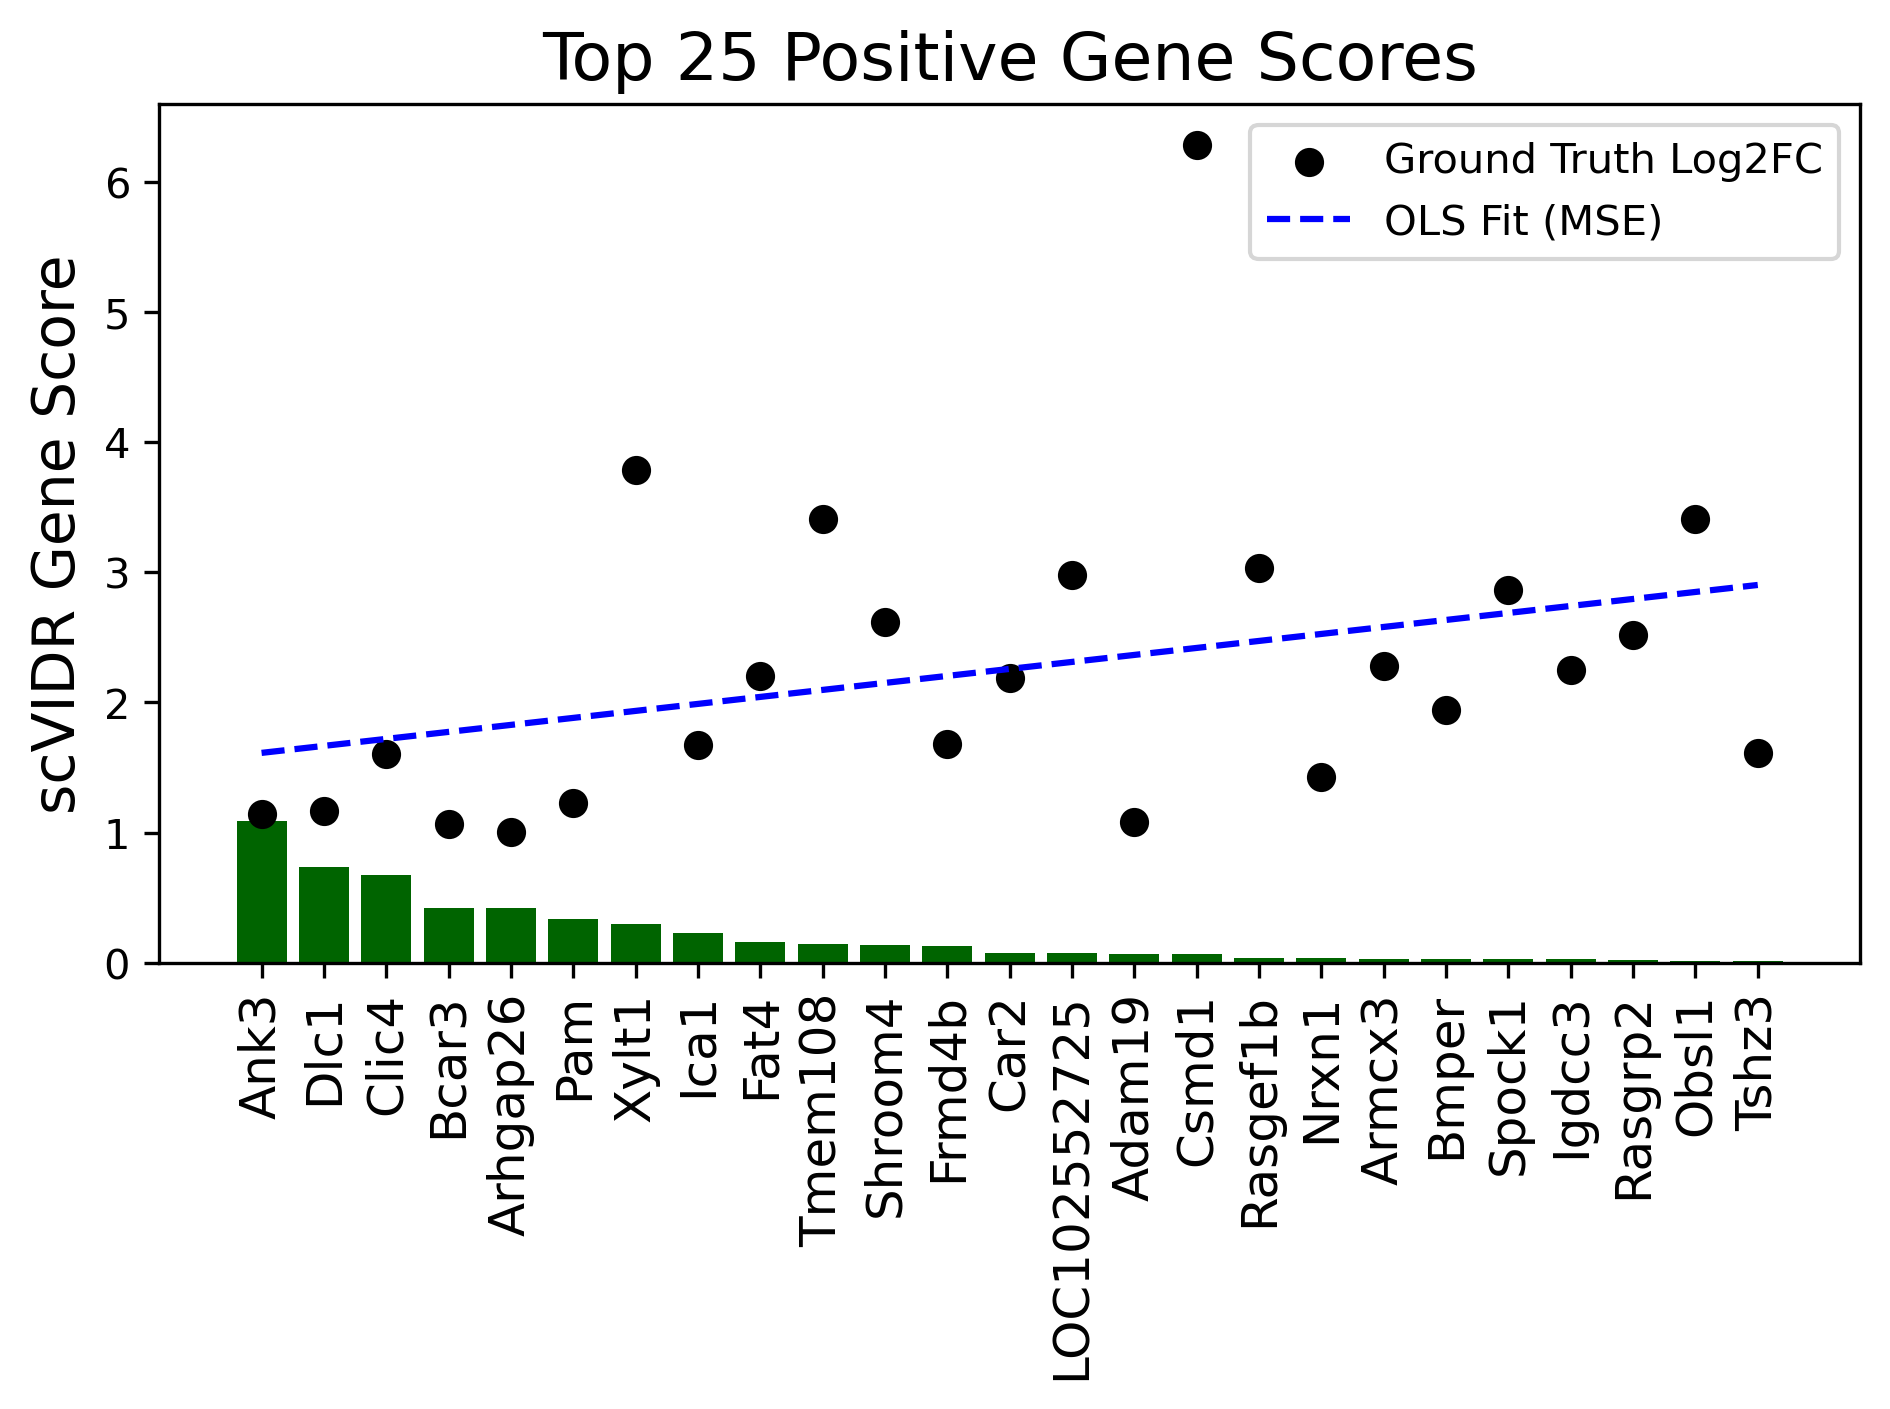

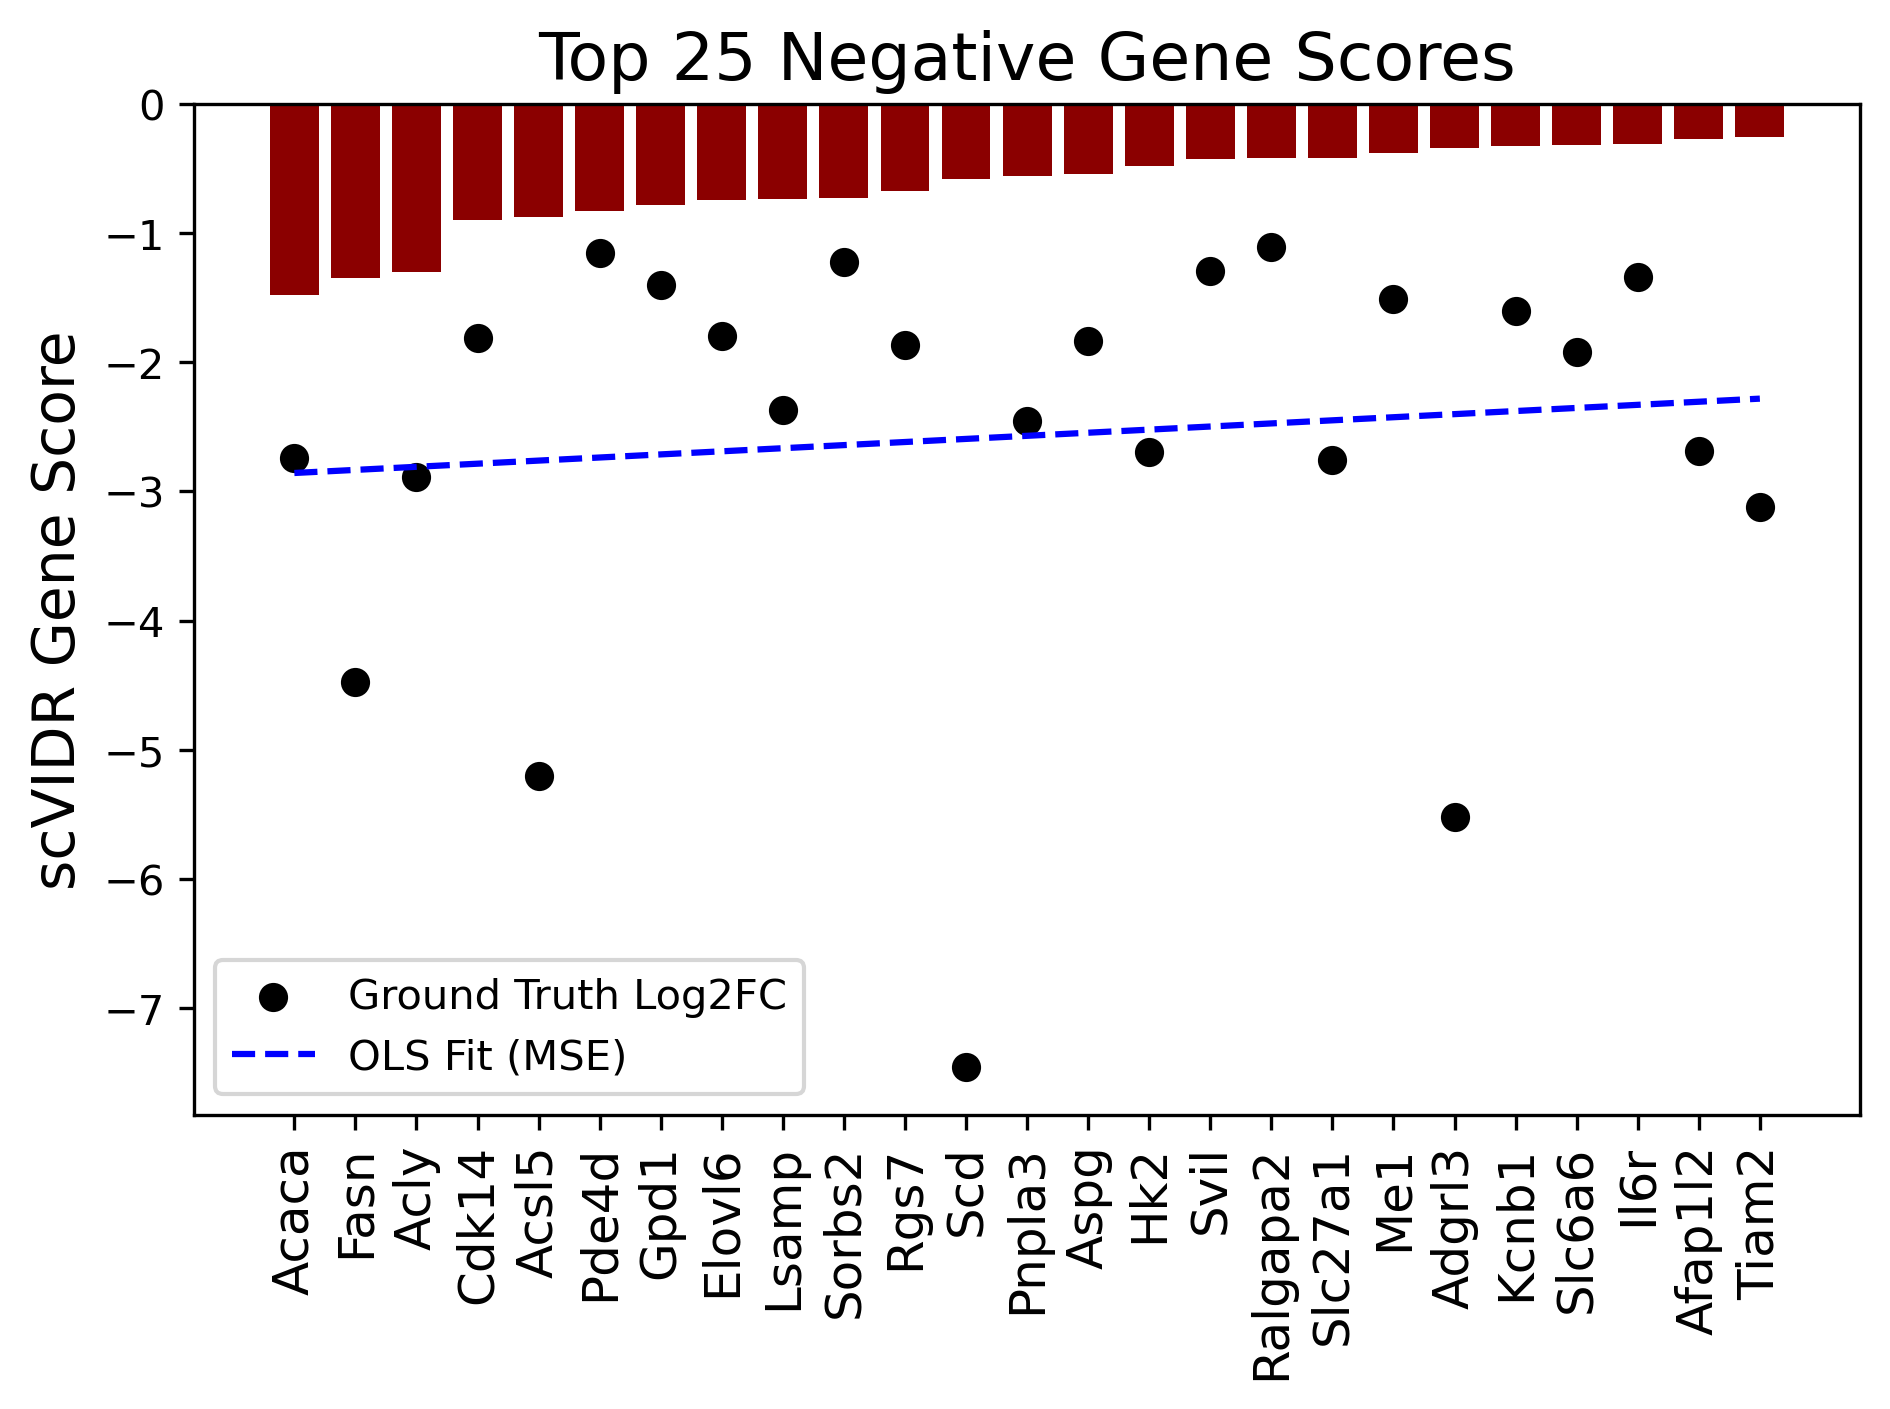

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import LinearRegression


# Top 25 most positive gene scores
top_pos = upregulated_predictions_24W_F.head(25)

plt.figure(dpi=300)
plt.bar(top_pos['Gene'], top_pos['Score'], color='darkgreen')
plt.scatter(top_pos['Gene'], top_pos['GroundTruthLog2FC'], color='black', label='Ground Truth Log2FC')



X = np.arange(len(top_pos['Gene'])).reshape(-1, 1)
y = top_pos['GroundTruthLog2FC'].values


ols = LinearRegression()
ols.fit(X, y)

y_pred = ols.predict(X)






plt.plot(top_pos['Gene'], y_pred, color='blue', linestyle='--', label='OLS Fit (MSE)')
plt.legend()

plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 25 Positive Gene Scores", fontsize=16)
plt.tight_layout()
#plt.savefig("../figures/Top25PositiveGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()




# Top 25 most negative gene scores
top_neg = downregulated_predictions_24W_F.head(25)
plt.figure(dpi=300)
plt.bar(top_neg['Gene'], top_neg['Score'], color='darkred')
plt.scatter(top_neg['Gene'], top_neg['GroundTruthLog2FC'], color='black', label='Ground Truth Log2FC')


X = np.arange(len(top_neg['Gene'])).reshape(-1, 1)
y = top_neg['GroundTruthLog2FC'].values


ols = LinearRegression()
ols.fit(X, y)

y_pred = ols.predict(X)

plt.plot(top_neg['Gene'], y_pred, color='blue', linestyle='--', label='OLS Fit (MSE)')
    
plt.xticks(rotation=90, fontsize=12)
plt.ylabel("scVIDR Gene Score", fontsize=14)
plt.title("Top 25 Negative Gene Scores", fontsize=16)
plt.legend()
plt.tight_layout()
#plt.savefig("../figures/Top25NegativeGeneScores_24W_Brown_Adipocytes_Both.svg", bbox_inches="tight")
plt.show()
